<a href="https://colab.research.google.com/github/Bootcamp-DA-P3/Proyecto-Olist-marketplace-de-Antony-Miguel-y-Carol/blob/main/notebooks/Proy_3_SQL_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto 3 - SQL a Python**
## **Procesamiento y limpieza de datos con Python**

En este proyecto cogemos información de un fichero .csv que hemos creado en un DataFrame con Python después de haberlo exportado con una SQL de una Base de Datos de MySQL Workbench.

El objetivo es hacer una limpieza más profunda de los datos después de haberlos filtrado en SQL.
  
Finalmente se mostrarán unas gráficas con el estudio sobre la calidad de los datos.

## 1. Importación.

1. Cargamos la información desde un fichero .csv y la agregamos a un DataFrame.

In [ ]:
import io
import pandas as pd
from google.colab import files

# 1. Muestra el botón para subir el archivo
uploaded = files.upload()

# 2. Verifica si se subió un archivo y lo carga en un DataFrame de Pandas
for filename in uploaded.keys():
    if filename.endswith(".csv"):
        df = pd.read_csv(io.BytesIO(uploaded[filename]))
        print(f"\n¡Archivo '{filename}' cargado con éxito!")
        display(df.head())  # Muestra las primeras filas
    else:
        print(
            "Por favor, selecciona un archivo con extensión .csv"
        )

In [ ]:
# Generamos una copia para comparar al final los cambios realizados.
df_old = df.copy()

## 2. Exploración inicial.

1. Vemos que información trae el dataframe para su estudio.

In [ ]:
# Detalle general del pd.DataFrame (Números de datos, tipos de datos, valores nulos)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34448 entries, 0 to 34447
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   seller_city_clean             34448 non-null  object 
 1   seller_state_clean            34448 non-null  object 
 2   seller_id                     34448 non-null  object 
 3   product_id                    34448 non-null  object 
 4   product_category_name         33838 non-null  object 
 5   unidades_vendidas_producto    34448 non-null  int64  
 6   pedidos_distintos_producto    34448 non-null  int64  
 7   ingreso_total_producto        34448 non-null  float64
 8   ranking_producto_en_vendedor  34448 non-null  int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 2.4+ MB


In [ ]:
# Número de filas y columnas.
df.shape

(34448, 9)

In [ ]:
# Lista las columnas del dataframe.
df.columns

Index(['seller_city_clean', 'seller_state_clean', 'seller_id', 'product_id',
       'product_category_name', 'unidades_vendidas_producto',
       'pedidos_distintos_producto', 'ingreso_total_producto',
       'ranking_producto_en_vendedor'],
      dtype='object')

In [ ]:
# Vemos que tipo de dato tenemos en cada columna
df.dtypes

,0
seller_city_clean,object
seller_state_clean,object
seller_id,object
product_id,object
product_category_name,object
unidades_vendidas_producto,int64
pedidos_distintos_producto,int64
ingreso_total_producto,float64
ranking_producto_en_vendedor,int64


2. Valores iniciales y finales del DataFrame.

In [ ]:
# Valores inicales (5 primeras filas)
df.head(5)

,seller_city_clean,seller_state_clean,seller_id,product_id,product_category_name,unidades_vendidas_producto,pedidos_distintos_producto,ingreso_total_producto,ranking_producto_en_vendedor
0,sao paulo,sp,955fee9216a65b617aa5c0531780ce60,aca2eb7d00ea1a7b8ebd4e68314663af,moveis_decoracao,527,431,37608.90,1
1,sao jose do rio preto,sp,1f50f920176fa81dab994f9023523100,422879e10f46682990de24d770e7f83d,ferramentas_jardim,484,352,26577.22,1
2,ibitinga,sp,4a3ca9315b744ce9f8e9374361493884,99a4788cb24856965c36a24e339b6058,cama_mesa_banho,482,461,42518.40,1
3,sao jose do rio preto,sp,1f50f920176fa81dab994f9023523100,389d119b48cf3043d311335e499d9c6b,ferramentas_jardim,392,311,21440.59,2
4,sao jose do rio preto,sp,1f50f920176fa81dab994f9023523100,368c6c730842d78016ad823897a372db,ferramentas_jardim,388,291,21056.80,3


In [ ]:
# Valores finales (5 últimas filas)
df.tail(5)

,seller_city_clean,seller_state_clean,seller_id,product_id,product_category_name,unidades_vendidas_producto,pedidos_distintos_producto,ingreso_total_producto,ranking_producto_en_vendedor
34443,sao paulo,sp,cf6f6bc4df3999b9c6440f124fb2f687,5304ff3fa35856a156e1170a6022d34d,artes,1,1,3.50,1
34444,franca,sp,9d7a1d34a5052409006425275ba1c2b4,2e8316b31db34314f393806fd7b6e185,papelaria,1,1,2.99,11
34445,curitiba,pr,48efc9d94a9834137efd9ea76b065a38,680cc8535be7cc69544238c1d6a83fe8,pet_shop,1,1,2.90,12
34446,francisco morato,sp,0e44d110fa6a54e121cb2c095a77762f,310dc32058903b6416c71faff132df9e,papelaria,1,1,2.29,5
34447,sao paulo,sp,2d2322d842118867781fc737e96d59a1,46fce52cef5caa7cc225a5531c946c8b,beleza_saude,1,1,2.20,5


## 3. Diagnóstico de datos.

1. Hacemos un análisis previo de los datos del dataframe para evaluar que acciones tomar.

In [ ]:
#Diagnostico de variables numericas y estadisticas.
df.describe()

,unidades_vendidas_producto,pedidos_distintos_producto,ingreso_total_producto,ranking_producto_en_vendedor
count,34448.000000,34448.000000,34448.000000,34448.000000
mean,3.270146,2.973322,394.555379,26.665031
std,10.025019,8.900459,1277.259292,38.152031
min,1.000000,1.000000,2.200000,1.000000
25%,1.000000,1.000000,59.900000,4.000000
50%,1.000000,1.000000,135.000000,12.000000
75%,3.000000,2.000000,319.965000,33.000000
max,527.000000,461.000000,63885.000000,281.000000


In [ ]:
# Diagnostico de valones nulos.
df.isna().sum()

,0
seller_city_clean,0
seller_state_clean,0
seller_id,0
product_id,0
product_category_name,610
unidades_vendidas_producto,0
pedidos_distintos_producto,0
ingreso_total_producto,0
ranking_producto_en_vendedor,0


In [ ]:
# Diagnostico de registros duplicados.
df.duplicated().sum()

np.int64(0)

## 4. Limpieza de datos.

se agrego una nueva colunna para que la suma de seller_city_clean y ranking de producto de vendedor y no des el total.


In [ ]:
# Convertir el número a texto y concatenar con la ciudad
df['nueva_columna'] = df['seller_city_clean'].astype(str) + ' - ' + df['ranking_producto_en_vendedor'].astype(str)

# Visualizar el resultado
df[['seller_city_clean', 'ranking_producto_en_vendedor', 'nueva_columna']].head()

,seller_city_clean,ranking_producto_en_vendedor,nueva_columna
0,sao paulo,1,sao paulo - 1
1,sao jose do rio preto,1,sao jose do rio preto - 1
2,ibitinga,1,ibitinga - 1
3,sao jose do rio preto,2,sao jose do rio preto - 2
4,sao jose do rio preto,3,sao jose do rio preto - 3


En la fila product_category_name (vacías) se agregó unknown para que vean que estos productos faltan por indentificar

In [ ]:
df['product_category_name'] = df['product_category_name'].fillna('unknown')
df['product_category_name']
df[df['product_category_name'] == 'unknown']

,seller_city_clean,seller_state_clean,seller_id,product_id,product_category_name,unidades_vendidas_producto,pedidos_distintos_producto,ingreso_total_producto,ranking_producto_en_vendedor
13,guarulhos,sp,c826c40d7b19f62a09e2d7c5e7295ee2,5a848e4ab52fd5445cdc07aab1c40e48,unknown,197,194,24229.03,1
174,santana de parnaiba,sp,1ca7077d890b907f89be8c954a02686a,b1d207586fca400a2370d50a9ba1da98,unknown,48,43,7152.00,1
323,guarulhos,sp,c826c40d7b19f62a09e2d7c5e7295ee2,76d1a1a9d21ab677a61c3ae34b1b352f,unknown,32,32,5712.64,2
366,guarulhos,sp,c826c40d7b19f62a09e2d7c5e7295ee2,ad88641611c35ebd59ecda07a9f17099,unknown,29,28,4515.33,3
367,guarulhos,sp,c826c40d7b19f62a09e2d7c5e7295ee2,3b60d513e90300a4e9833e5cda1f1d61,unknown,29,28,4393.33,4
...,...,...,...,...,...,...,...,...,...
34386,sao paulo,sp,52f0fe436a347ddad7ed5f9aa4e27eaa,05cf9ac595f28386ee763c98cbc2bad0,unknown,1,1,6.99,15
34400,fernando prestes,sp,60da8bfa7eebe230b7d66ac4082d79b3,b77b1c083bc9bd1bbceccc2346cd02f4,unknown,1,1,6.80,2
34430,atibaia,sp,d2f3e277560ed4c6361284429b00f037,28fff36d13d492328583ee2b1d72f78f,unknown,1,1,5.20,5
34434,atibaia,sp,d2f3e277560ed4c6361284429b00f037,2cd7d0ade9eb52c856a16dce303397ad,unknown,1,1,4.85,6


In [ ]:
import numpy as np

# 1. Cargar el archivo CSV ignorando líneas corruptas o incompletas con el nombre correcto
df = pd.read_csv('df3_vendedores_popularidad.csv', on_bad_lines='skip')

# 2. Estandarizar nombres de columnas (eliminar espacios y convertir a minúsculas)
df.columns = df.columns.str.strip().str.lower()

# 3. Limpiar espacios en blanco innecesarios en todas las columnas de texto
string_columns = df.select_dtypes(include=['object']).columns
for col in string_columns:
    df[col] = df[col].astype(str).str.strip()

# 4. Estandarizar el código de estado a mayúsculas (ej: 'sp' -> 'SP')
df['seller_state_clean'] = df['seller_state_clean'].str.upper()

# 6. Convertir tipos de datos numéricos
numeric_integers = [
    'unidades_vendidas_producto',
    'pedidos_distintos_producto',
    'ranking_producto_en_vendedor'
]

for col in numeric_integers:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

df['ingreso_total_producto'] = pd.to_numeric(df['ingreso_total_producto'], errors='coerce')

# 7. Eliminar filas con datos cuantitativos incompletos (como la última fila truncada)
df = df.dropna(subset=['ingreso_total_producto', 'unidades_vendidas_producto'])

# 8. Eliminar registros duplicados si existieran
df = df.drop_duplicates().reset_index(drop=True)

print(f"--- Limpieza finalizada ---")
print(f"Registros válidos procesados: {len(df)}")
print(f"Columnas procesadas: {list(df.columns)}")

--- Limpieza finalizada ---
Registros válidos procesados: 34448
Columnas procesadas: ['seller_city_clean', 'seller_state_clean', 'seller_id', 'product_id', 'product_category_name', 'unidades_vendidas_producto', 'pedidos_distintos_producto', 'ingreso_total_producto', 'ranking_producto_en_vendedor']


 ## 5. Validación.

1. Vamos a realizar una comprobación rápida de valores nulos entre el DataFrame original y el actual mediante una gráfica.

Dataframe Original

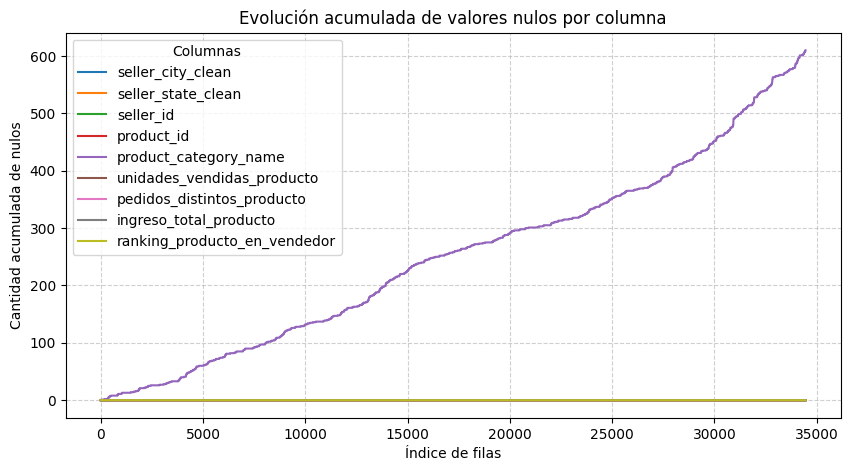

In [ ]:
import matplotlib.pyplot as plt

# Columnas que vamos a analizar
columnas = ['seller_city_clean', 'seller_state_clean', 'seller_id', 'product_id', 'product_category_name', 'unidades_vendidas_producto', 'pedidos_distintos_producto', 'ingreso_total_producto', 'ranking_producto_en_vendedor']

# Creamos un DataFrame booleano (True si es nulo, False si no)
# Suma de forma acumulada a lo largo de los registros
nulos_acumulados = df_old[columnas].isna().cumsum()

# Crear la gráfica
plt.figure(figsize=(10, 5))
plt.plot(nulos_acumulados)

plt.title('Evolución acumulada de valores nulos por columna')
plt.xlabel('Índice de filas')
plt.ylabel('Cantidad acumulada de nulos')
plt.legend(columnas, title='Columnas')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Dataframe tras la limpieza.

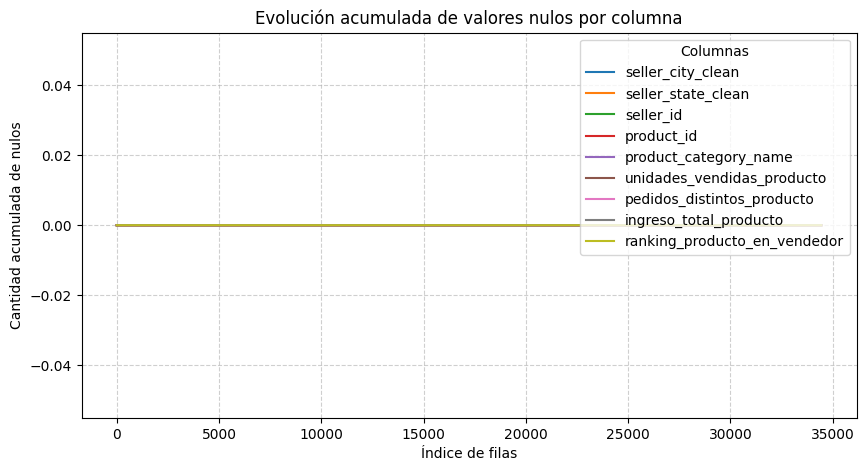

In [ ]:
# Columnas que vamos a analizar
columnas = ['seller_city_clean', 'seller_state_clean', 'seller_id', 'product_id', 'product_category_name', 'unidades_vendidas_producto', 'pedidos_distintos_producto', 'ingreso_total_producto', 'ranking_producto_en_vendedor']

# Creamos un DataFrame booleano (True si es nulo, False si no)
# Suma de forma acumulada a lo largo de los registros
nulos_acumulados = df[columnas].isna().cumsum()

# Crear la gráfica
plt.figure(figsize=(10, 5))
plt.plot(nulos_acumulados)

plt.title('Evolución acumulada de valores nulos por columna')
plt.xlabel('Índice de filas')
plt.ylabel('Cantidad acumulada de nulos')
plt.legend(columnas, title='Columnas')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

## Exportación del dataset limpio.

In [ ]:
# Importamos esta libreria para poder guardar el fichero en el ordenador desde el que se está ejecuntando y no en la nube del drive.
from google.colab import files

# Guardar el DataFrame temporalmente en el entorno de Colab
# (encoding='utf-8-sig' asegura que tildes y caracteres especiales se vean bien en Excel)
df.to_csv('datos_limpios.csv', index=False, encoding='utf-8-sig')

# Disparar la descarga en el navegador
files.download('datos_limpios.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>